In [3]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Pointing the path to the import and parameter files
import sys
sys.path.insert(0, '../../')
# Import list
from imports import *
# Parameter list
import param as pm

In [5]:
# Returning the date/time of observation or unix time
fname, dtime=tools.timepoint(fname=pm.file, date=None)

fs_slice=1100
fe_slice=1350

Date of observation: 2019-02-25 02:40:11
Fname: 1551055211


## Full satellite optimized


In [170]:
sat_full = ss(file_name=fname,          
             sats_only=None, 
             data_loc=pm.data_save, 
             sat_loc=pm.data_save,
             survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency], 
             sat_info=pm.satellite_catalogue,
             plots_loc=pm.data_plot,
             sat_beam=pm.beam_model+'_beam_'+str(pm.fs)+'_'+str(pm.fe)+'MHz', 
             frequency_range=[pm.fs,pm.fe], 
             constellations=pm.constellations_remain,
             nearby_satellites=pm.nearby_constellations,
             verbose=True)


if pm.mask==True:
    name=pm.degree+'deg'
else:
    name='no'

    sat_full_info = pickle.load(open(pm.data_save+pm.folder+'full_'+name+'_mask_satellite_f_'+str(pm.fs)+'_'+str(pm.fe)+'MHz__'+str(fs_slice)+'_'+str(fe_slice)+'MHz.p', 'rb'))
f_alpha = sat_full_info['best-fit']


print ('\nAlpha:'+str(f_alpha)+'\n Chi Square: '+str()+str(sat_full_info['chi2_value'])+'\n Chi Square N: '+str()+str(sat_full_info['chi2_div']))

Number of constellations:  6
Number of signals in satellite catalog:  32


FileNotFoundError: [Errno 2] No such file or directory: '/idia/projects/hi_im/brandon/meerkat_gain_cali/1551055211/sat_2/full_no_mask_satellite_f_1000_1500MHz__1100_1350MHz.p'

### Running

In [ ]:
sat_full.excecute(a_param=f_alpha,
                 obs_time_start=pm.nd_s0[0], obs_time_end=pm.nd_s0[-1], 
                 obs_frequency_start=1250, obs_frequency_end=1350, 
                 file_bias_choice=pm.bias, 
                 add_sub=[1, 1], 
                 band_lvl=[None, None], 
                 bandsize=None,
                 verbose=True)


### Side work

In [60]:
bandsize=10

In [61]:
print (combined_con_list)
for con_b in sat_full.cons:
    print (con_b)
    if con_b=='BDS' and 'beidou' in combined_con_list:
        bds_in = True

NameError: name 'combined_con_list' is not defined

In [62]:
sat_bs = {'GAL':'galileo', 
           'BDS':'beidou', 
           'GLO':'glo-ops', 
           'GPS':'gps-ops', 
           'SBAS':'sbas', 
           'IRNSS':'irnss', 
           'QZS':'qzs'}

sat_sb = {'galileo':'GAL', 
           'beidou':'BDS', 
           'glo-ops':'GLO', 
           'gps-ops':'GPS', 
           'sbas':'SBAS', 
           'irnss':'IRNSS', 
           'qzs':'QZS'}

In [296]:
bandsize=10
masks=[]
masked_array = np.zeros(sat_full.frequency_band.shape) * np.zeros(sat_full.nd_s0.shape)[:, np.newaxis]
# Checking all the cosntelletion where there is a satellite that comes nearby
for sat_key in sat_full.nearby_sats_time.keys():
    if len(sat_full.nearby_sats_time[sat_key])!=0:
        constellation_nearby_idx=sat_full.nearby_sats_time[sat_key]
        # Creating a masked array for each constellation
        masked_array = np.zeros(sat_full.frequency_band.shape) * np.zeros(sat_full.nd_s0.shape)[:, np.newaxis]
        
        if bandsize==None:
            # Masks through all channels
            masked_array[constellation_nearby_idx, :]=1
            masks.append(masked_array)
            
        else:
            # Masking specific frequency channels
            print (sat_key)
            frequency_vals = np.unique(sat_full.sat_data[sat_full.sat_data['Sys'].str.contains(con_b)]['Frequency[MHz]'].values)  # this line sorted
            print (frequency_vals)


            
            
            

# masks=np.array(masks)
# mask_sum = np.sum(masks, axis=0)
# mask_sum[mask_sum>0]=1

galileo
[]
glo-ops
[]


In [302]:
constellation_nearby

array([328, 329, 330, 331, 332, 333, 334, 335, 346])

In [303]:
sat_full.cons

['GAL', 'BDS', 'GLO', 'GPS', 'SBAS', 'IRNSS']

In [304]:
np.where(test>0)

(array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3]), array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

In [305]:
constellation_nearby = list(sat_full.nearby_sats_time.keys())[idx]


In [306]:
combined_con_list = '\t'.join(sat_full.nearby_sats_time.keys())
masks = []
bds_in=False

for con_b in sat_full.cons:
        
    if con_b.lower() in combined_con_list:
        frequency_vals = np.unique(sat_full.sat_data[sat_full.sat_data['Sys'].str.contains(con_b)]['Frequency[MHz]'].values)  # this line sorted
        if bds_in==True:
            idx = [idx for idx,con_i in enumerate(sat_full.nearby_sats_time.keys()) if 'beidou' in con_i][0]
        else:
            idx = [idx for idx,con_i in enumerate(sat_full.nearby_sats_time.keys()) if con_b.lower() in con_i][0]

        constellation_nearby = list(sat_full.nearby_sats_time.keys())[idx]
        print (constellation_nearby)
        # Frequency
        freq_step = sat_full.frequency_band[1]-sat_full.frequency_band[0]
        # Maksed array being made
        masked_array = np.zeros(sat_full.frequency_band.shape) * np.zeros(sat_full.nd_s0.shape)[:, np.newaxis]
        
        # Masks through all channels
        if bandsize==None:
            masked_array[sat_full.nearby_sats_time[constellation_nearby], :]=1
            masks.append(masked_array)

        # Makes a block for the mask data
        else:
            idx_range = int(np.round(bandsize/freq_step, 0))

            frequency_idx = [np.where(fval > sat_full.frequency_band)[0][-1]+1 for fval in frequency_vals]    # getting the idx of the frequency values for 1 constellation
            frequency_range_idx = np.unique(np.array([np.arange(-idx_range+fval, idx_range+fval) for fval in frequency_idx]))
            print (frequency_range_idx)
            for fi in frequency_range_idx:
                masked_array[sat_full.nearby_sats_time[constellation_nearby], fi]=1

            masks.append(masked_array)
                


# mask = np.array(masks)
# total_mask= 0
# for mask_i in mask:
#     total_mask+=mask_i




galileo
[1284 1285 1286 1287 1288 1289 1290 1291 1292 1293 1294 1295 1296 1297
 1298 1299 1300 1301 1302 1303 1304 1305 1306 1307 1308 1309 1310 1311
 1312 1313 1314 1315 1316 1317 1318 1319 1320 1321 1322 1323 1324 1325
 1326 1327 1328 1329 1330 1331 1332 1333 1334 1335 1336 1337 1338 1339
 1340 1341 1342 1343 1344 1345 1346 1347 1348 1349 1350 1351 1352 1353
 1354 1355 1356 1357 1358 1359 1360 1361 1362 1363 1364 1365 1366 1367
 1368 1369 1370 1371 1372 1373 1374 1375 1376 1377 1378 1379 1380 1381
 1382 1383]
glo-ops
[]
gps-ops
[]
irnss
[]


### Normal work

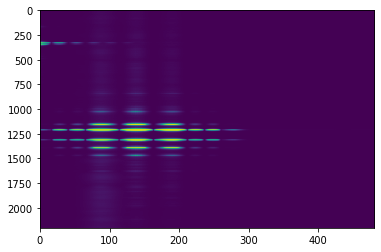

In [161]:
plt.imshow(sat_full.calibration_data_slice.T, aspect='auto')
plt.show()

# plt.plot(freq_band[sat_full.frequency_idx[0]:sat_full.frequency_idx[1]], np.log10(np.mean(sat_full.calibration_data_slice.T, axis=0)))
# plt.plot(freq_band[sat_full.frequency_idx[0]:sat_full.frequency_idx[1]], np.log10(np.mean(sat_full.simulation_TOD_slice.T ,axis=0)))
# plt.show()



In [144]:
# plt.plot(frange_slice, sat_full.calibration_data_slice.T[1900])

In [150]:
frequency_band = sat_full.frequency_band[1436:1677]

In [174]:
frequency_band[-1]

1350.2

In [170]:
frequency_band2 = sat_full.frequency_band[sat_full.frequency_idx[0]:sat_full.frequency_idx[1]]

In [175]:
np.where(frequency_band2>1350)[0][0]

480

In [111]:
np.where(sat_full.calibration_data_original.T==np.max(sat_full.calibration_data_original.T))

(array([1212]), array([1453]))

In [ ]:
sa

In [156]:
sat_full.simulation_TOD_slice.shape

(481, 2204)

(17.0, 60.0)

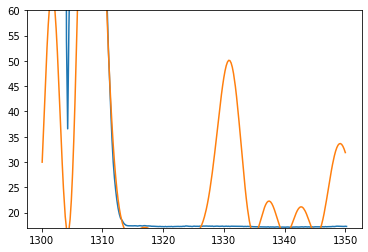

In [181]:
plt.plot(frequency_band, (sat_full.calibration_data_original.T[1212, 1436:1677]))
plt.plot(frequency_band2[240:480], (sat_full.simulation_TOD_slice.T[1212, 240:480]))

plt.ylim(17,60)

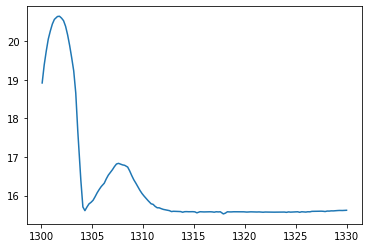

In [97]:
plt.plot(freq_band[1436:1580], np.mean(sat_full.calibration_data_original.T[:, 1436:1580],axis=0))

In [103]:
masked = np.ma.array(data=sat_full.calibration_data_original.T[:, 1436:1580], mask=sat_full.mask_nearby_satellites[:, 1436:1580])


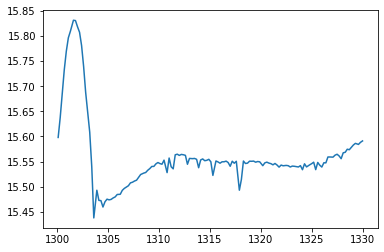

In [104]:
plt.plot(freq_band[1436:1580], np.ma.mean(masked,axis=0))

In [162]:
# Frequency slice inside the 1000-1500 MHz range
frange_slice = sat_full.frequency_band[sat_full.frequency_idx[0]:sat_full.frequency_idx[1]]   # Frequency range in the slice

# Time slice inside the  range 774-6474 seconds
ts_slice = sat_full.nd_s0[sat_full.time_idx[0]]   # Starting time
te_slice = sat_full.nd_s0[sat_full.time_idx[1]-1]   # Ending  time


# Fully optimized calibrated data slice
full_cds = sat_full.calibration_data_slice.T
## Masked
full_cds_masked = np.ma.array(data=full_cds, mask=sat_full.mask_nearby_satellites_slice)

## Fully optimized simulated data slice
full_sts = sat_full.simulation_TOD_slice.T
## Masked
full_sts_masked = np.ma.array(data=full_sts, mask=sat_full.mask_nearby_satellites_slice)


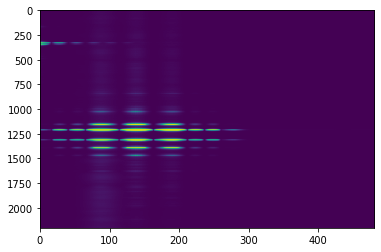

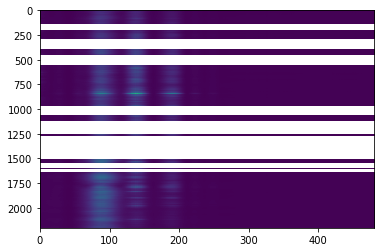

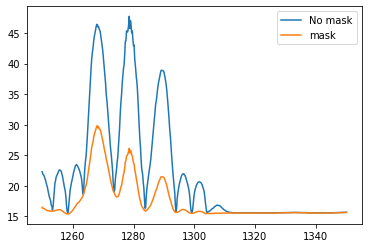

In [163]:
plt.imshow(full_cds, aspect='auto')
plt.show()
plt.imshow(full_cds_masked, aspect='auto')
plt.show()
plt.plot(frange_slice, np.mean(full_cds, axis=0), label='No mask')
plt.plot(frange_slice, np.ma.mean(full_cds_masked, axis=0), label='mask')
plt.legend()

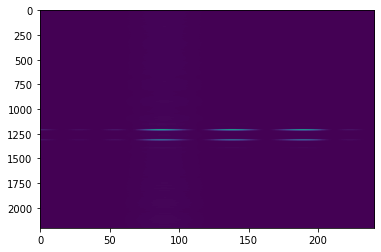

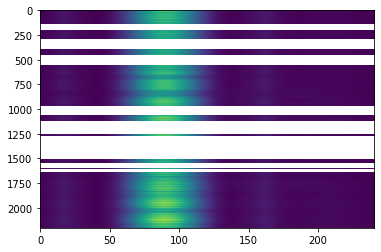

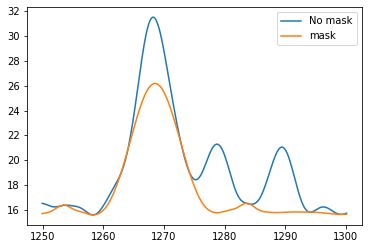

In [67]:
plt.imshow(full_sts, aspect='auto')
plt.show()
plt.imshow(full_sts_masked, aspect='auto')
plt.show()
plt.plot(frange_slice, np.mean(full_sts, axis=0), label='No mask')
plt.plot(frange_slice, np.ma.mean(full_sts_masked, axis=0), label='mask')
plt.legend()

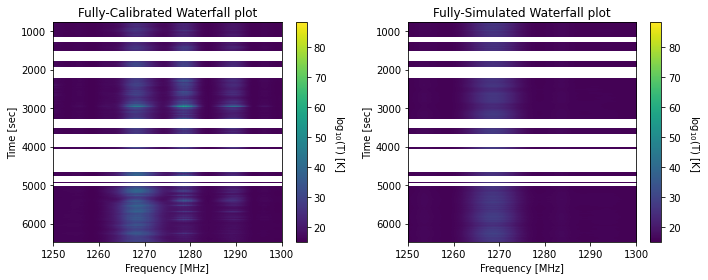

In [68]:
ext_fs = [fs_slice, fe_slice , te_slice, ts_slice]
vmxf, vmnf = np.ma.max(([full_cds_masked, full_sts_masked])),np.ma.min(([full_cds_masked, full_sts]))


fig, axs = plt.subplots(figsize=(10,4), nrows=1, ncols=2)
ax=axs[0]
ax.set_title('Fully-Calibrated Waterfall plot')
hb=ax.imshow((full_cds_masked), aspect='auto', extent=ext_fs, vmin=vmnf, vmax=vmxf)
cbar=plt.colorbar(hb, ax=ax)
cbar.set_label(r'log$_{10}$(T) [K]', rotation=270, labelpad=20, y=0.45)
ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')

ax=axs[1]
ax.set_title('Fully-Simulated Waterfall plot')
hb=ax.imshow((full_sts_masked), aspect='auto', extent=ext_fs, vmin=vmnf, vmax=vmxf)
cbar=plt.colorbar(hb, ax=ax)
cbar.set_label(r'log$_{10}$(T) [K]', rotation=270, labelpad=20, y=0.45)
ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')

fig.tight_layout()

In [23]:
# # Averaging 10sec over
# bins=np.arange(nd_s0[0], nd_s0[-1], 10)   # 10 represents 10sec
# inds = np.digitize(x=nd_s0, bins=bins)
# #
# simulation_avg = np.ma.array([full_sts_masked.T[:, inds==i].mean(axis=1) for i in np.unique(inds)])
# data_avg = np.ma.array([full_cds_masked.T[:, inds==i].mean(axis=1) for i in np.unique(inds)])

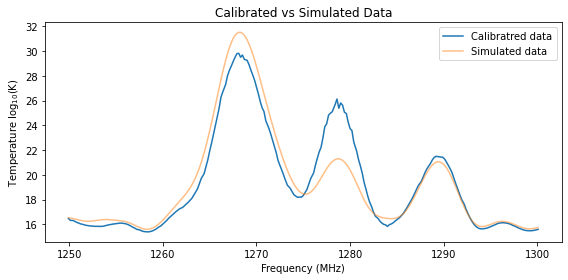

In [69]:
full_cds_f = np.ma.mean(full_cds_masked, axis=0)    # Frequency plane - calibrated data slice
full_sts_f = np.ma.mean(full_sts, axis=0)    # Frequency plabe - simulated data slice

plt.figure(figsize=(8, 4))
plt.plot(frange_slice, (full_cds_f), label='Calibratred data')
plt.plot(frange_slice, (full_sts_f), alpha=0.5, label='Simulated data')

plt.title('Calibrated vs Simulated Data')
plt.xlabel('Frequency (MHz)')
plt.ylabel(r'Temperature log$_{10}$(K)')

plt.legend()
plt.tight_layout()

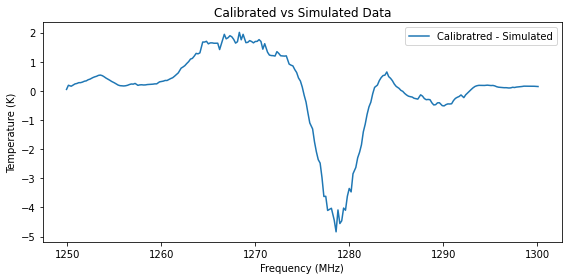

In [70]:
plt.figure(figsize=(8, 4))
plt.plot(frange_slice, full_sts_f - full_cds_f, label='Calibratred - Simulated')

plt.title('Calibrated vs Simulated Data')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Temperature (K)')

plt.legend()
plt.tight_layout()

## Chunk optimized data

In [15]:
# Extracting and storing values for each chunk
c_alpha = []    # Alpha values
c_time = []     # Time values
for c_i in range(22):
    c_file = pickle.load(open(pm.data_save+folder+'parallel_5deg_mask_satellite_chunk_'+str(c_i)+'_f_'+str(pm.fs)+'_'+str(pm.fe)+'MHz__'+str(fs_slice)+'_'+str(fe_slice)+'MHz_v2.p', 'rb'))
    c_alpha.append(c_file['best-fit'])
    c_time.append(c_file['time'])

c_alpha = np.array(c_alpha)
c_time = np.array(c_time)

In [16]:
c_alpha

array([[29.99999919, 29.99999921, 29.99999855, 29.99999855, 29.99999855],
       [29.99999855, 29.99999855, 29.99999855, 29.99999918, 29.99999919],
       [29.99999855, 29.99999919, 29.99999855, 29.99999924, 29.99999855],
       [29.99999922, 29.99999855, 29.99999855, 29.99999921, 29.99999921],
       [29.99999855, 29.99999855, 29.99999855, 29.99999927, 29.99999855],
       [29.99999921, 29.99999918, 29.99999919, 29.99999855, 29.99999922],
       [29.99999923, 29.99999924, 29.99999927, 29.99999855, 29.99999918],
       [29.99999927, 29.99999855, 29.99999855, 29.9999992 , 29.99999855],
       [29.99999855, 29.99999855, 29.99999918, 29.99999855, 29.99999919],
       [29.99999855, 29.99999855, 29.99999921, 29.99999918, 29.99999922],
       [29.99999926, 29.99999921, 29.99999924, 29.99999921, 29.99999855],
       [29.99999923, 29.99999855, 29.99999923, 29.99999855, 29.99999855],
       [29.99999926, 29.99999919, 29.99999855, 29.99999924, 29.99999855],
       [29.99999919, 29.99999855, 29.9

In [17]:
# fig, axs = plt.subplots(7, 3, figsize=(21,18), sharex=False)
# fig.subplots_adjust()

# for r_plot in range(7):
#     for c_plot in range(3):
#         ax=axs[r_plot, c_plot]
        
#         try:
#             ax.set_title('Alpha '+str(3*r_plot+c_plot))
#             ax.plot(c_alpha[:, 3*r_plot+c_plot], 'r.',label='Chunk data')
#             ax.axhline(f_alpha[3*r_plot+c_plot], color='k', ls='--', label='Full data')
#         except IndexError:
#             continue
        
#         if 3*r_plot+c_plot > 17:
#             ax.set_xlabel('Chunk #')
#         ax.legend()


# plt.tight_layout()
# plt.show()

In [18]:
sat_chunk = ss(file_name=fname,          
             sats_only=None, 
             data_loc=pm.data_save, 
             sat_loc=pm.data_save,
             survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency], 
             sat_info=pm.satellite_catalogue,
             plots_loc=pm.data_plot,
             sat_beam=pm.beam_model+'_beam_'+str(pm.fs)+'_'+str(pm.fe)+'MHz', 
             frequency_range=[pm.fs,pm.fe], 
             constellations=pm.constellations_remain,
             nearby_satellites=pm.nearby_constellations,
             verbose=True)

Number of constellations:  6
Number of signals in satellite catalog:  32


In [19]:
# Excecuting each chunk with their respective alpha values
c_waterfall = []
for c_i in range(22):   
    sat_chunk.excecute(a_param=c_alpha[c_i], 
                       obs_time_start=c_time[c_i][0], 
                       obs_time_end=c_time[c_i][-1], 
                       obs_frequency_start=fs_slice, obs_frequency_end=fe_slice, 
                       file_bias_choice=pm.bias, 
                       add_sub=[1, 1], 
                       band_lvl=[None, None], 
                       bandsize=None,
                       verbose=False)
    
    # Chunck simulated and calibrated data slices
    c_cds = sat_chunk.calibration_data_slice.T
    # Mask
    c_cds_masked = np.ma.array(data=sat_chunk.calibration_data_slice, mask=sat_chunk.mask_nearby_satellites_slice.T).T
    ##    
    c_sts = sat_chunk.simulation_TOD_slice.T
    # Mask
    c_sts_masked = np.ma.array(data=sat_chunk.simulation_TOD_slice, mask=sat_chunk.mask_nearby_satellites_slice.T).T
    ##
    c_waterfall.append(np.ma.array([c_cds_masked, c_sts_masked]))
    
c_waterfall = np.ma.array(c_waterfall)

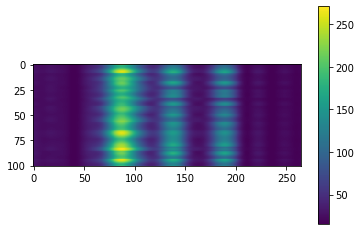

In [20]:
plt.imshow(c_waterfall[0,1])
plt.colorbar()

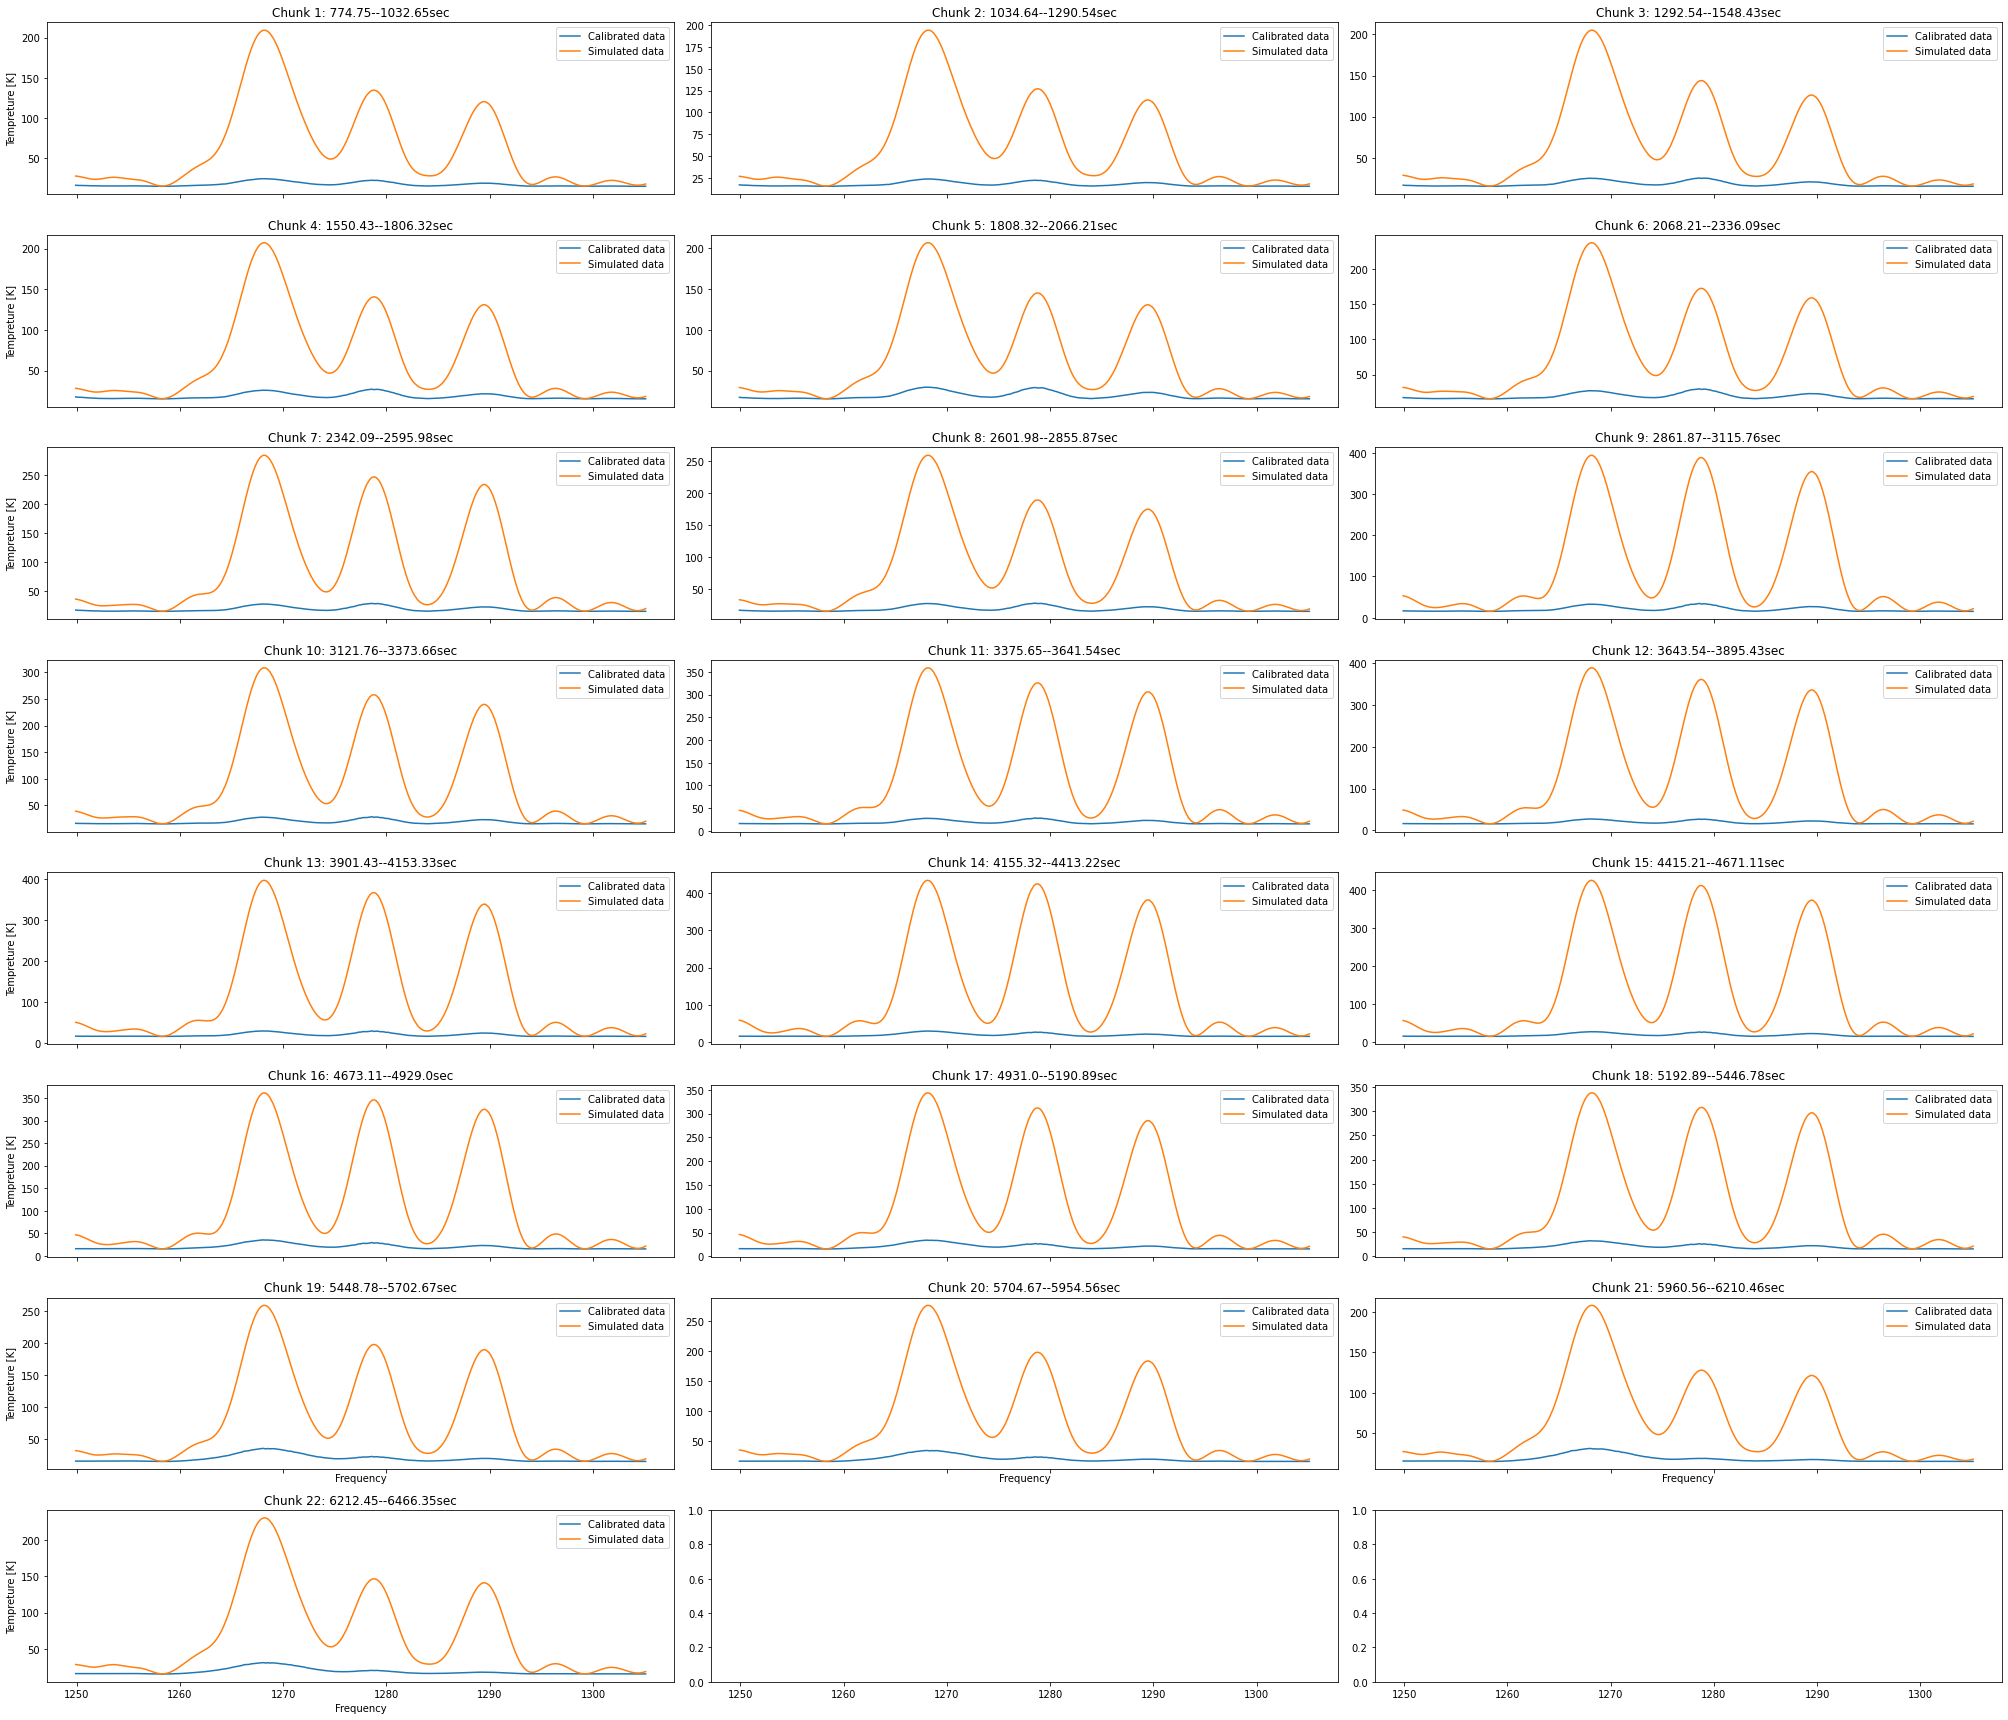

In [19]:
fig, axs = plt.subplots(8, 3, figsize=(28,24), sharex=True, sharey=False)
fig.subplots_adjust()

for r_plot in range(8):
    for c_plot in range(3):
    
        try:
            ax=axs[r_plot, c_plot]
            times = pm.nd_s0[(3*r_plot+c_plot)*100:(3*r_plot+c_plot)*100+100]
            ax.plot(frange_slice, np.ma.mean(c_waterfall[3*r_plot+c_plot, 0,:,:], axis=0), label='Calibrated data')
            ax.plot(frange_slice, np.ma.mean(c_waterfall[3*r_plot+c_plot, 1,:,:], axis=0), label='Simulated data')

            ax.set_title('Chunk '+str(3*r_plot+c_plot+1)+': '+str(np.round(times[0],2))+'--'+str(np.round(times[-1],2))+'sec')

            if 3*r_plot+c_plot > 17:
                ax.set_xlabel('Frequency')
            if c_plot==0:
                ax.set_ylabel('Tempreture [K]')
            ax.legend()
        except IndexError:
            continue
        
plt.tight_layout()
# plt.savefig('/users/bengelbrecht/scrap_fig/chunk_fit_frequency-1250_1305.pdf')
plt.show()

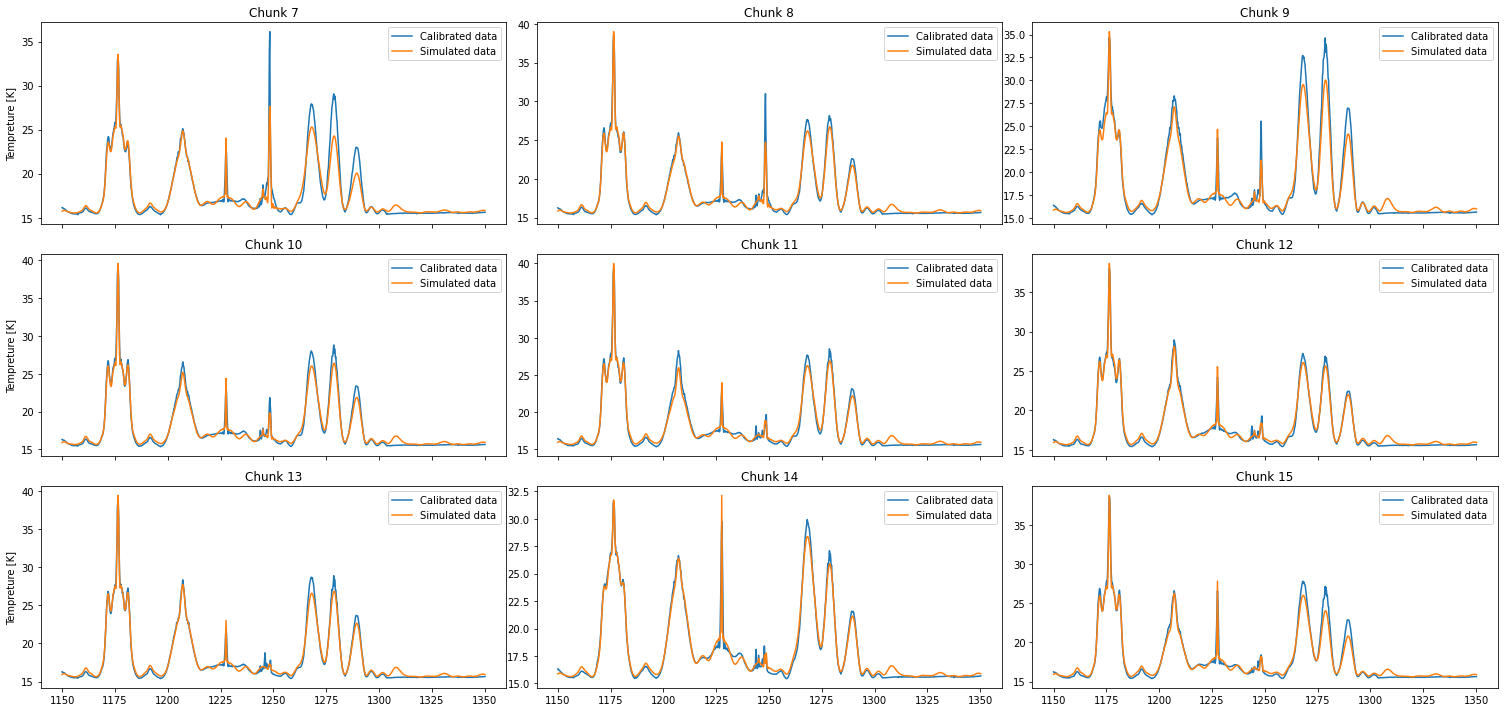

In [242]:
# Looks at a smaller cut
num = 6
fig, axs = plt.subplots(3, 3, figsize=(21,10), sharex=True, sharey=False)
fig.subplots_adjust()

for r_plot in range(3):
    for c_plot in range(3):
    
        try:
            ax=axs[r_plot, c_plot]

            ax.plot(frange_slice, np.ma.mean(c_waterfall[3*r_plot+c_plot+num, 0,:,:], axis=0), label='Calibrated data')
            ax.plot(frange_slice, np.ma.mean(c_waterfall[3*r_plot+c_plot+num, 1,:,:], axis=0), label='Simulated data')

            ax.set_title('Chunk '+str(3*r_plot+c_plot+1+num))

            if 3*r_plot+c_plot > 17:
                ax.set_xlabel('Frequency')
            if c_plot==0:
                ax.set_ylabel('Tempreture [K]')
            ax.legend()
        except IndexError:
            continue
        
plt.tight_layout()
# plt.savefig('/users/bengelbrecht/scrap_fig/fitting_shorter_frequency_range_2.pdf')
plt.show()

In [ ]:

stop

## Comparing to different frequencies

In [34]:
sat_full = ss(file_name=fname, 
         sats_only=None, 
         data_loc=meerkat_data_path, 
         sat_loc=meerkat_data_path,
         survey_info=[nd_s0, nd_s0_coords, frequency], 
         sat_info=satellite_catalogue,
         plots_loc=data_plot,
         sat_beam='emss_r', 
         frequency_range=[fs,fe], 
         constellations=cons,
         nearby_satellites=nearby_constellation_path,
         verbose=True)

# sat_full_info = pickle.load(open(data_save+folder+'full_no_mask_satellite_chunk.p', 'rb'))
flist = ['', '_2',  '_3', '_4']
f_alpha_all = []
for val in flist:
    sat_full_info = pickle.load(open(data_save+folder+'full_5deg_mask_satellite_chunk_shorter_frequency'+val+'.p', 'rb'))

    f_alpha_all.append(sat_full_info['best-fit'])



Number of constellations:  6
Number of signals in satellite catalog:  32
Number of signals inside choice frequency range:  21


In [35]:
# Extracting and storing values for each chunk
c_alpha_all = []
for val in flist:
    c_alpha = []    # Alpha values
    c_time = []     # Time values
    for c_i in range(22):
        c_file = pickle.load(open(data_save+folder+'parallel_5deg_mask_satellite_chunk_'+str(c_i)+'_shorter_frequency'+val+'.p', 'rb'))
        c_alpha.append(c_file['best-fit'])
        c_time.append(c_file['time'])

    c_alpha = np.array(c_alpha)
    c_time = np.array(c_time)
    c_alpha_all.append(c_alpha)
c_alpha_all = np.array(c_alpha_all)

In [36]:
c_alpha_all.shape

(4, 22, 21)

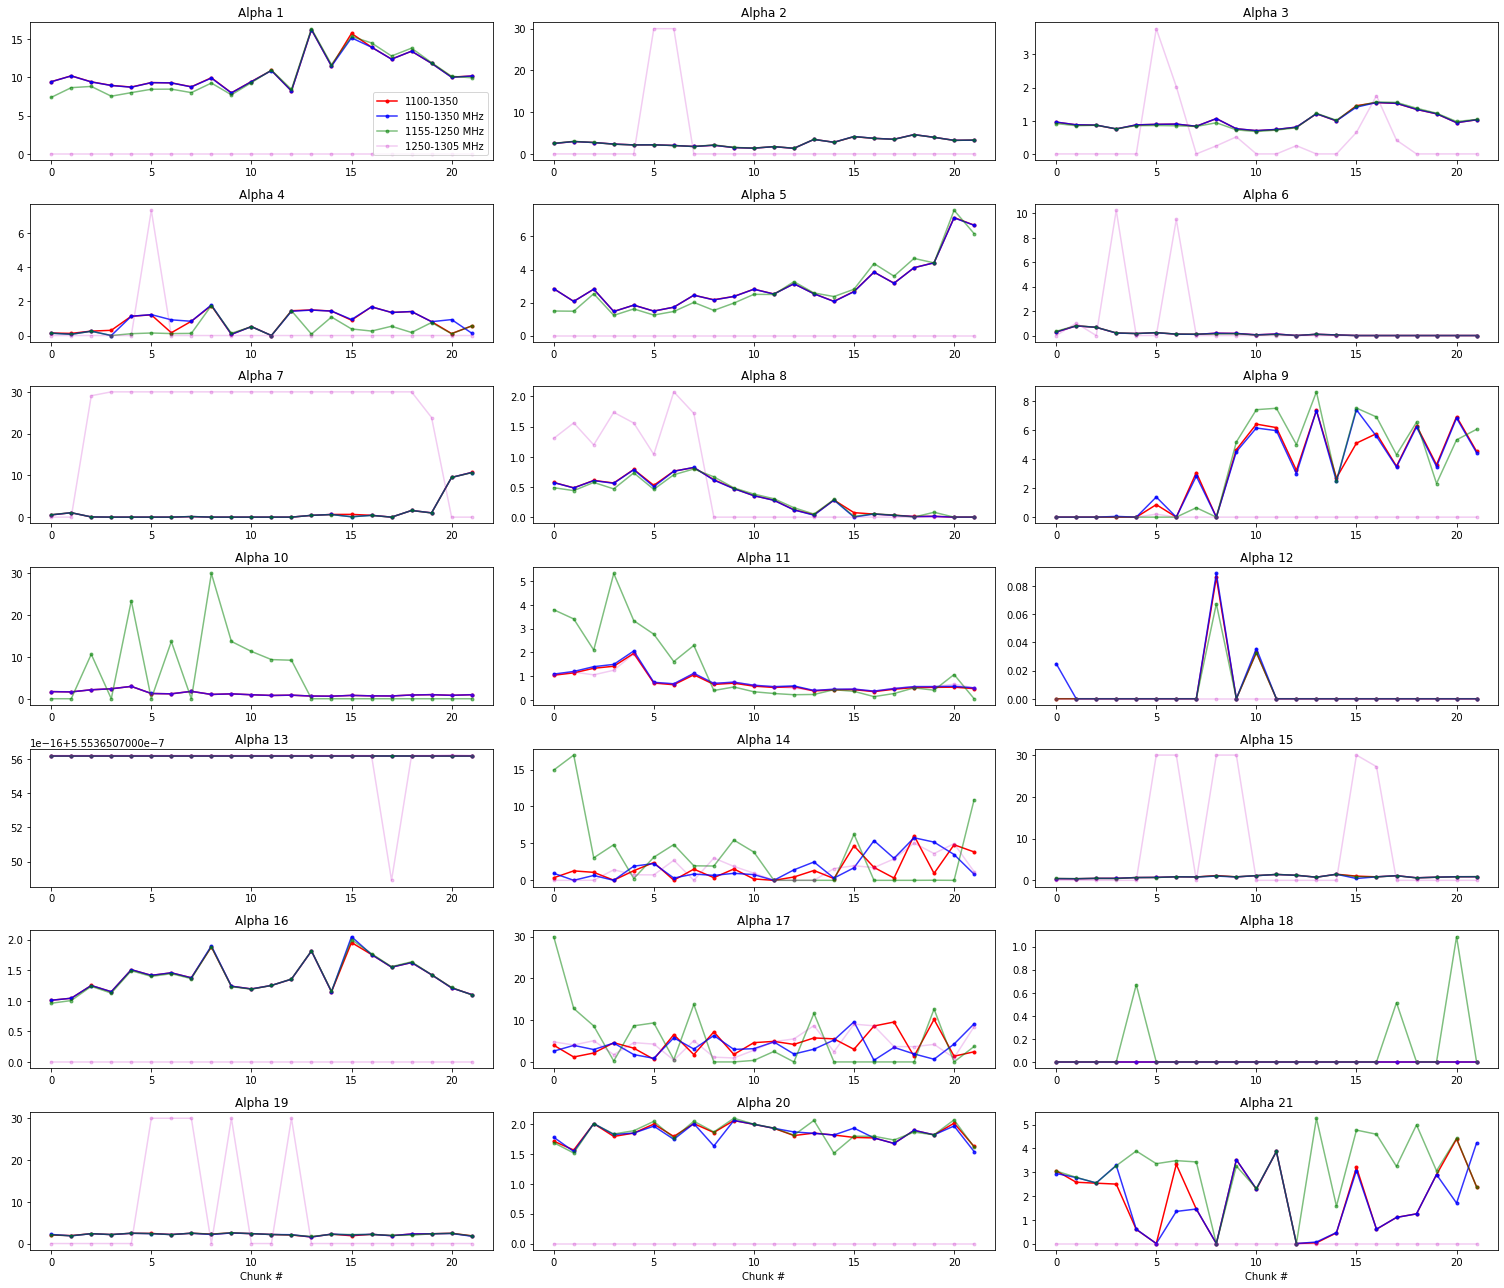

In [40]:
fig, axs = plt.subplots(7, 3, figsize=(21,18), sharex=False)
fig.subplots_adjust()

for r_plot in range(7):
    for c_plot in range(3):
        ax=axs[r_plot, c_plot]
        
        try:
            ax.set_title('Alpha '+str(3*r_plot+c_plot+1))
            ax.plot(c_alpha_all[0, :, 3*r_plot+c_plot], 'r.-',alpha=1, label='1100-1350')
            ax.plot(c_alpha_all[1, :, 3*r_plot+c_plot], 'b.-',alpha=0.8, label='1150-1350 MHz')
            ax.plot(c_alpha_all[2, :, 3*r_plot+c_plot], 'g.-',alpha=0.5, label='1155-1250 MHz')
            ax.plot(c_alpha_all[3, :, 3*r_plot+c_plot], 'm.-',alpha=0.2, label='1250-1305 MHz')

        except IndexError:
            continue
        
        if 3*r_plot+c_plot > 17:
            ax.set_xlabel('Chunk #')
        if 3*r_plot+c_plot ==0:
            ax.legend()


plt.tight_layout()
plt.savefig('/users/bengelbrecht/scrap_fig/chunk_alpha_values.pdf')
plt.show()

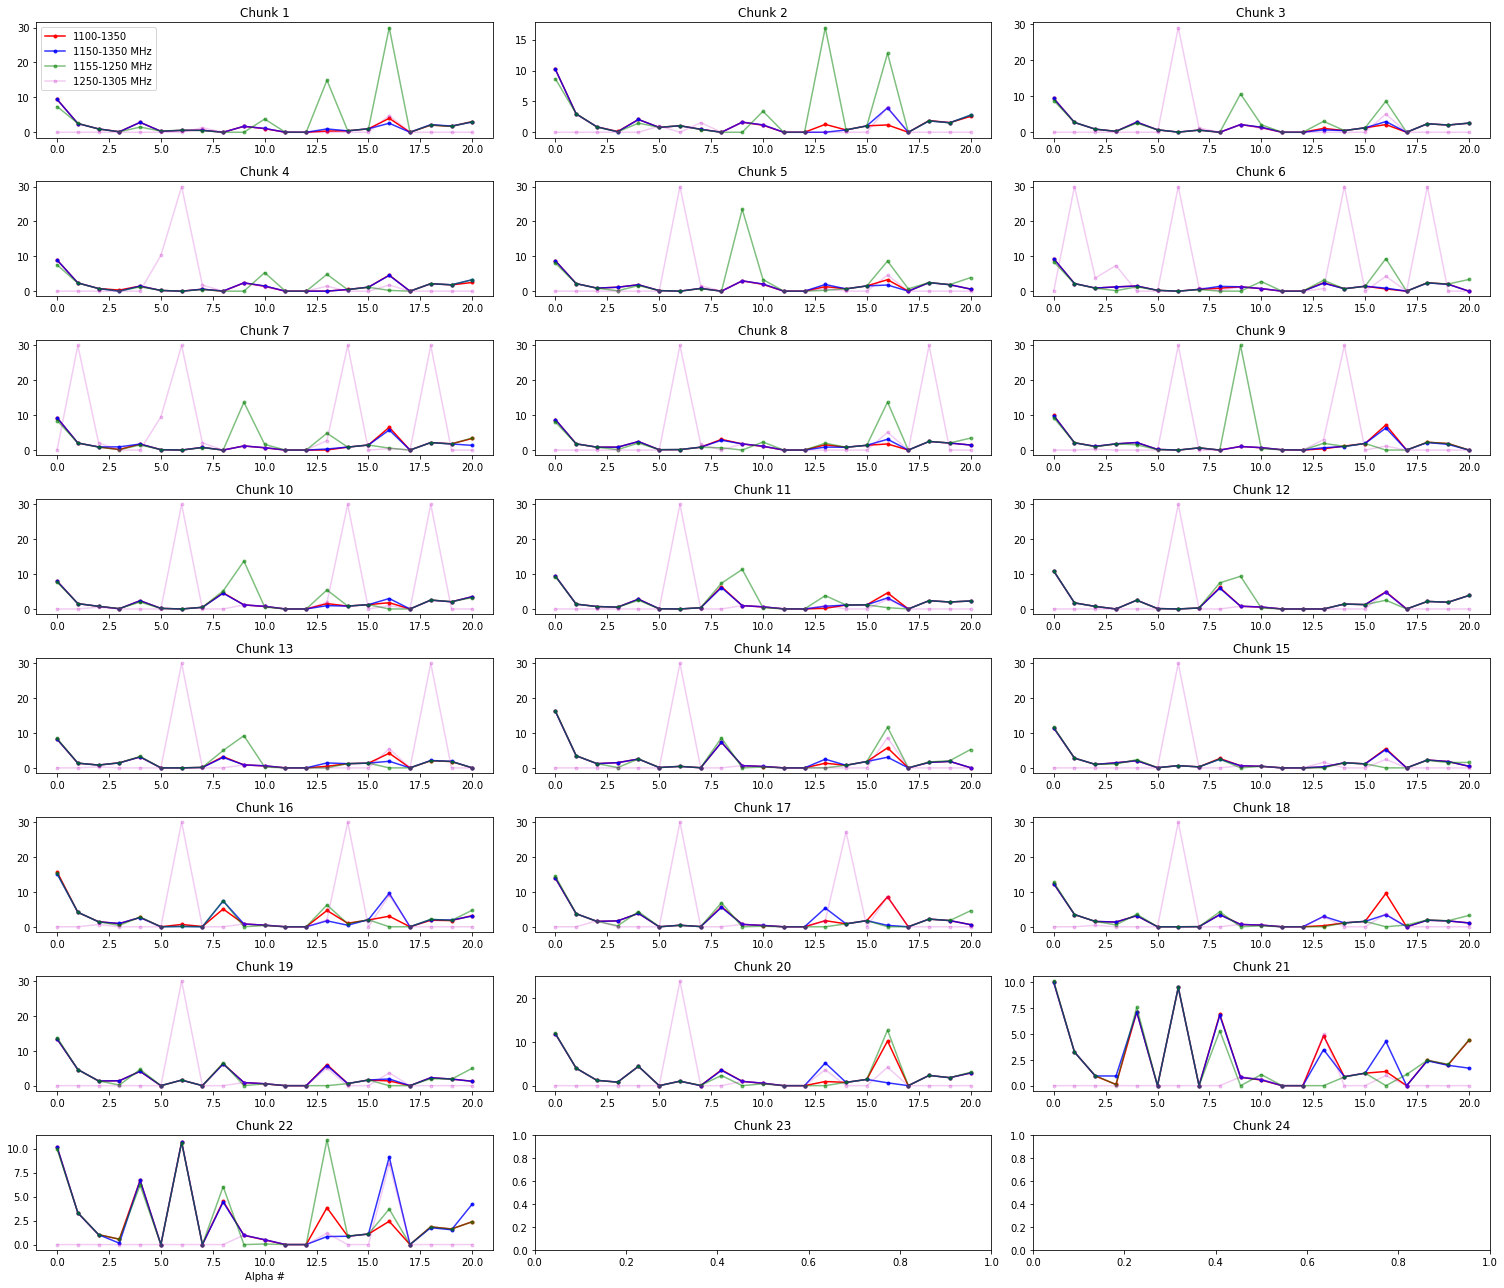

In [49]:
fig, axs = plt.subplots(8, 3, figsize=(21,18), sharex=False)
fig.subplots_adjust()

for r_plot in range(8):
    for c_plot in range(3):
        ax=axs[r_plot, c_plot]
        
        try:
            ax.set_title('Chunk '+str(3*r_plot+c_plot+1))
            ax.plot(c_alpha_all[0, 3*r_plot+c_plot, :] , 'r.-',alpha=1, label='1100-1350')
            ax.plot(c_alpha_all[1, 3*r_plot+c_plot, :], 'b.-',alpha=0.8, label='1150-1350 MHz')
            ax.plot(c_alpha_all[2, 3*r_plot+c_plot,:], 'g.-',alpha=0.5, label='1155-1250 MHz')
            ax.plot(c_alpha_all[3, 3*r_plot+c_plot,:], 'm.-',alpha=0.2, label='1250-1305 MHz')

        except IndexError:
            continue
        
        if 3*r_plot+c_plot > 20:
            ax.set_xlabel('Alpha #')
        if 3*r_plot+c_plot ==0:
            ax.legend()


plt.tight_layout()
plt.savefig('/users/bengelbrecht/scrap_fig/alpha_chunk_values.pdf')
plt.show()

## Plots

##### PSD plots


In [3]:
f = np.arange(-100,100, 0.1)

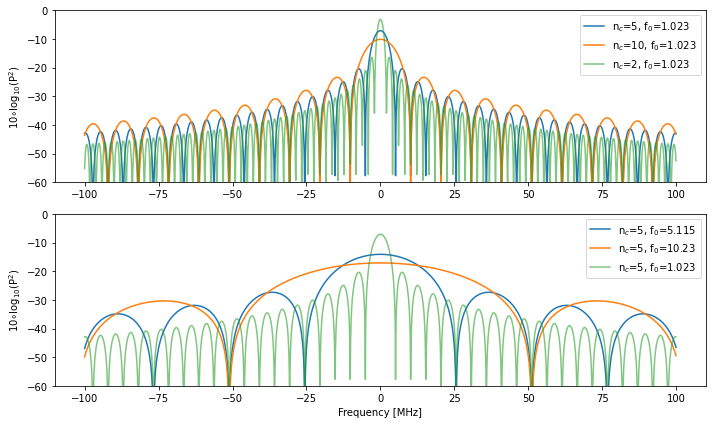

In [36]:
## BPSK

fig, (ax1, ax2) = plt.subplots(figsize=(10,6), nrows=2, ncols=1)

ax=ax1
ax.plot(f, 10*np.log10(psd.BPSK(f=f, n_c=5, f0=1.023)), label=r'n$_c$=5, f$_0$=1.023')
ax.plot(f, 10*np.log10(psd.BPSK(f=f, n_c=10, f0=1.023)), label=r'n$_c$=10, f$_0$=1.023')
ax.plot(f, 10*np.log10(psd.BPSK(f=f, n_c=2, f0=1.023)), alpha=0.6, label=r'n$_c$=2, f$_0$=1.023')

ax.set_ylabel(r'10$\circ$log$_{10}$(P$^2$)')
ax.set_ylim(-60, 0)
ax.legend()

ax=ax2
ax.plot(f, 10*np.log10(psd.BPSK(f=f, n_c=5, f0=5.115)), label=r'n$_c$=5, f$_0$=5.115')
ax.plot(f, 10*np.log10(psd.BPSK(f=f, n_c=5, f0=10.23)), label=r'n$_c$=5, f$_0$=10.23')
ax.plot(f, 10*np.log10(psd.BPSK(f=f, n_c=5, f0=1.023)), alpha=0.6, label=r'n$_c$=5, f$_0$=1.023')

ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel(r'10$\circ$log$_{10}$(P$^2$)')
ax.set_ylim(-60, 0)
ax.legend()

fig.tight_layout()
plt.savefig('/idia/projects/hi_im/brandon/thesis_plots/PSD/bpsk.pdf', bbox_inches='tight')

In [27]:
# BOC

bocs_e = psd.BOC(f=f, n_c=5 ,n_s=10, f0=5.115)
bocs_o = psd.BOC(f=f, n_c=2 ,n_s=5, f0=2.046)

bocc_e = psd.BOCc(f=f, n_c=5 ,n_s=10, f0=5.115)
bocc_o = psd.BOCc(f=f, n_c=2 ,n_s=5, f0=2.046)

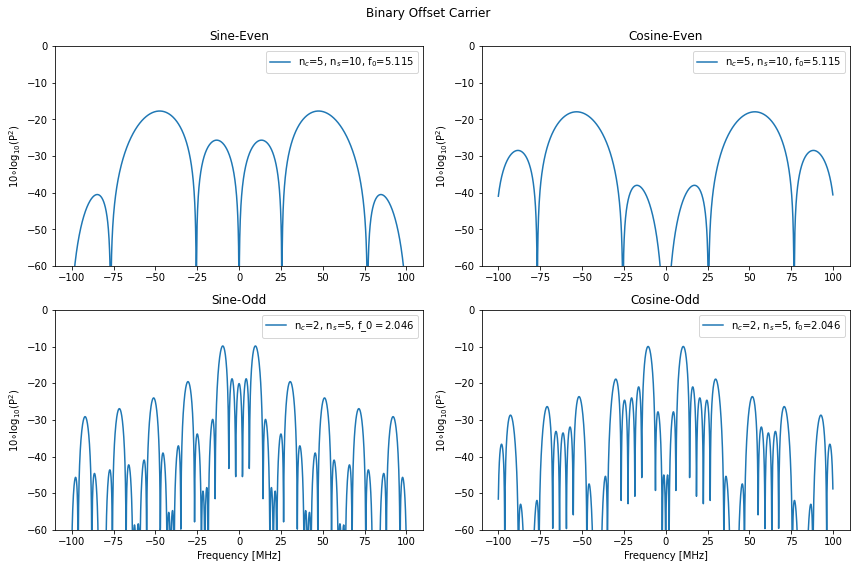

In [47]:
## BOC

fig, axs = plt.subplots(figsize=(12,8), nrows=2, ncols=2)
fig.suptitle('Binary Offset Carrier')
ax=axs[0,0]
ax.set_title('Sine-Even')
ax.plot(f, 10*np.log10(bocs_e), label=r'n$_c$=5, n$_s$=10, f$_0$=5.115')
ax.set_ylabel(r'10$\circ$log$_{10}$(P$^2$)')
ax.set_ylim(-60, 0)
ax.legend()

ax=axs[1,0]
ax.set_title('Sine-Odd')
ax.plot(f, 10*np.log10(bocs_o), label=r'n$_c$=2, n$_s$=5, f_$0=$2.046')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel(r'10$\circ$log$_{10}$(P$^2$)')
ax.set_ylim(-60, 0)
ax.legend()

ax=axs[0,1]
ax.set_title('Cosine-Even')
ax.plot(f, 10*np.log10(bocc_e), label=r'n$_c$=5, n$_s$=10, f$_0$=5.115')
ax.set_ylabel(r'10$\circ$log$_{10}$(P$^2$)')
ax.set_ylim(-60, 0)
ax.legend()

ax=axs[1,1]
ax.set_title('Cosine-Odd')
ax.plot(f, 10*np.log10(bocc_o), label=r'n$_c$=2, n$_s$=5, f$_0$=2.046')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel(r'10$\circ$log$_{10}$(P$^2$)')
ax.set_ylim(-60, 0)
ax.legend()

fig.tight_layout()
plt.savefig('/idia/projects/hi_im/brandon/thesis_plots/PSD/boc.pdf', bbox_inches='tight')

<ipython-input-45-2d427bc3d5b2>:5: RuntimeWarning: divide by zero encountered in log10
  ax.plot(f, 10*np.log10(psd.altBOC(f=f, n_c=10, n_s=15, f0=5.115)), label=r'n$_c$=10, n$_s$=15, f$_0$=5.115')
<ipython-input-45-2d427bc3d5b2>:6: RuntimeWarning: divide by zero encountered in log10
  ax.plot(f, 10*np.log10(psd.altBOC(f=f, n_c=10, n_s=15, f0=10.23)), label=r'n$_c$=10, n$_s$=15, f$_0$=10.23')
<ipython-input-45-2d427bc3d5b2>:14: RuntimeWarning: divide by zero encountered in log10
  ax.plot(f, 10*np.log10(psd.altBOC(f=f, n_c=2, n_s=15, f0=5.115)), label=r'n$_c$=2, n$_s$=15, f$_0$=5.115')
<ipython-input-45-2d427bc3d5b2>:15: RuntimeWarning: divide by zero encountered in log10
  ax.plot(f, 10*np.log10(psd.altBOC(f=f, n_c=5, n_s=15, f0=5.115)), label=r'n$_c$=5, n$_s$=15, f$_0$=5.115')


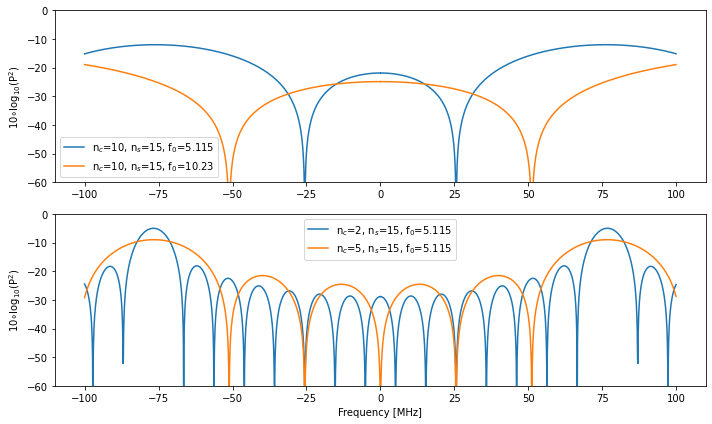

In [45]:
# ALTBOC
fig, (ax1, ax2) = plt.subplots(figsize=(10,6), nrows=2, ncols=1)

ax=ax1
ax.plot(f, 10*np.log10(psd.altBOC(f=f, n_c=10, n_s=15, f0=5.115)), label=r'n$_c$=10, n$_s$=15, f$_0$=5.115')
ax.plot(f, 10*np.log10(psd.altBOC(f=f, n_c=10, n_s=15, f0=10.23)), label=r'n$_c$=10, n$_s$=15, f$_0$=10.23')


ax.set_ylabel(r'10$\circ$log$_{10}$(P$^2$)')
ax.set_ylim(-60, 0)
ax.legend()

ax=ax2
ax.plot(f, 10*np.log10(psd.altBOC(f=f, n_c=2, n_s=15, f0=5.115)), label=r'n$_c$=2, n$_s$=15, f$_0$=5.115')
ax.plot(f, 10*np.log10(psd.altBOC(f=f, n_c=5, n_s=15, f0=5.115)), label=r'n$_c$=5, n$_s$=15, f$_0$=5.115')

ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel(r'10$\circ$log$_{10}$(P$^2$)')
ax.set_ylim(-60, 0)
ax.legend()

fig.tight_layout()
plt.savefig('/idia/projects/hi_im/brandon/thesis_plots/PSD/altboc.pdf', bbox_inches='tight')

##### Masking

In [100]:
def masking_vals(name):
    mask_path = '/idia/projects/hi_im/brandon/meerkat_gain_cali/1551055211/nearby_satellites/nearby_satellite_close_angle_'+str(name)+'.p'
    d = pickle.load(open(mask_path, 'rb'), encoding='latin1')    
    
    maps = np.ones((len(pm.nd_s0), len(pm.frequency)))
    mask_vals = np.sort(np.concatenate([d[key] for key in d.keys() if len(d[key])>0]))

    maps[mask_vals, :]=0
    
    return maps*-1+1

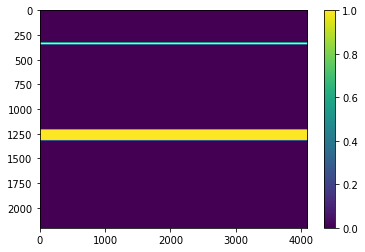

In [106]:
plt.imshow(masking_vals('1_fill'), aspect='auto')
plt.colorbar()

In [131]:
ext_mask = [pm.frequency[0], pm.frequency[-1], pm.nd_s0[-1], pm.nd_s0[0]]

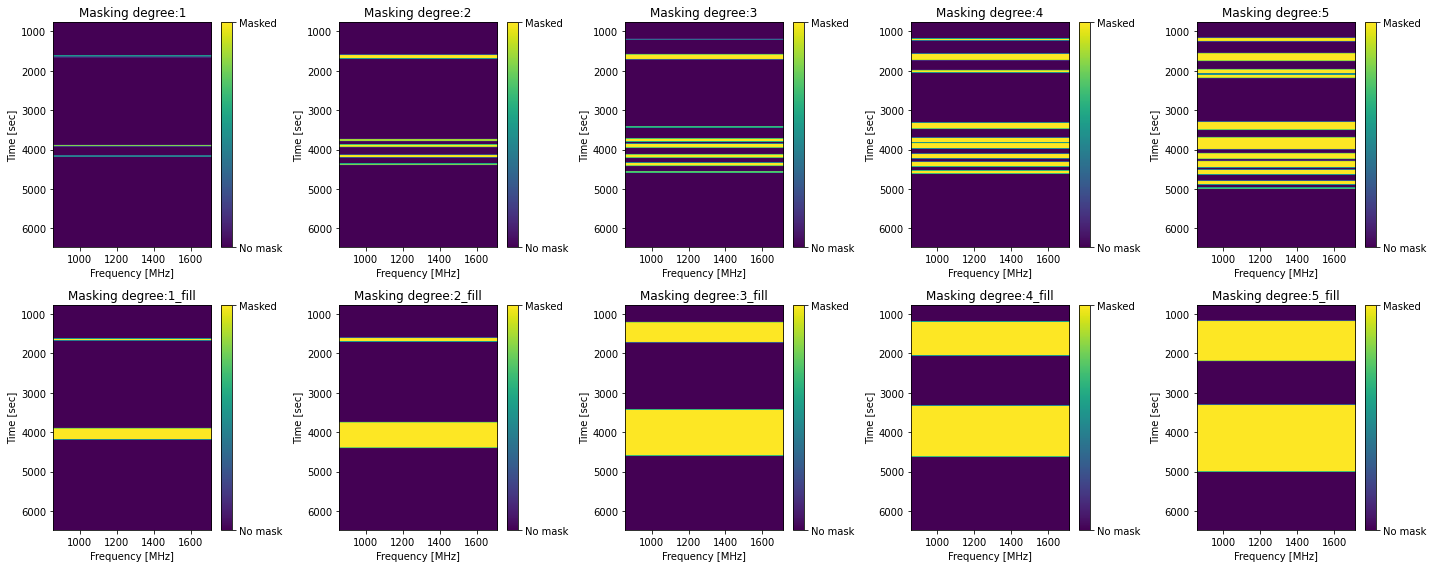

In [139]:
fig, axs = plt.subplots(figsize=(20, 8), nrows=2, ncols=5)

for idx in range(10):

    if idx<5:
        row=0
        choice=str(idx+1)
    else:
        row=1
        choice=str(idx-4)+'_fill'
        idx=idx-5

    ax=axs[row, idx]
    im = ax.imshow(masking_vals(choice), aspect='auto', extent=ext_mask)
    cb = plt.colorbar(im, ax=ax, ticks=[0,1])
    cb.ax.set_yticklabels(['No mask','Masked'])  # vertically oriented colorbar
    
    ax.set_title('Masking degree:'+choice)
    ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Time [sec]')
    
fig.tight_layout()
fig.savefig(pm.data_plot+'sat_pos/masking_degree_levels.pdf', format='pdf', bbox_inches='tight')